# Project Pythia Notebook Template

Let's start here! If you can directly link to an image relevant to your notebook, such as [canonical logos](https://github.com/numpy/numpy/blob/main/doc/source/_static/numpylogo.svg), do so here at the top of your notebook. You can do this with MyST Markdown syntax, outlined in [this MyST guide](https://mystmd.org/guide/figures), or you edit this cell to see a demonstration. **Be sure to include `alt` text for any embedded images to make your content more accessible.**

```{image} ../thumbnails/thumbnail.png
:alt: Project Pythia logo
:width: 200px
```

Next, title your notebook appropriately with a top-level Markdown header, `#` (see the very first cell above). Do not use this level header anywhere else in the notebook. Our book build process will use this title in the navbar, table of contents, etc. Keep it short, keep it descriptive. 

Follow this with a `---` cell to visually distinguish the transition to the prerequisites section.

---

## Overview
If you have an introductory paragraph, lead with it here! Keep it short and tied to your material, then be sure to continue into the required list of topics below,

1. This is a numbered list of the specific topics
1. These should map approximately to your main sections of content
1. Or each second-level, `##`, header in your notebook
1. Keep the size and scope of your notebook in check
1. And be sure to let the reader know up front the important concepts they'll be leaving with

## Prerequisites
This section was inspired by [this template](https://github.com/alan-turing-institute/the-turing-way/blob/master/book/templates/chapter-template/chapter-landing-page.md) of the wonderful [The Turing Way](https://the-turing-way.netlify.app) Jupyter Book.

Following your overview, tell your reader what concepts, packages, or other background information they'll **need** before learning your material. Tie this explicitly with links to other pages here in Foundations or to relevant external resources. Remove this body text, then populate the Markdown table, denoted in this cell with `|` vertical brackets, below, and fill out the information following. In this table, lay out prerequisite concepts by explicitly linking to other Foundations material or external resources, or describe generally helpful concepts.

Label the importance of each concept explicitly as **helpful/necessary**.

| Concepts | Importance | Notes |
| --- | --- | --- |
| [Intro to Cartopy](https://foundations.projectpythia.org/core/cartopy/cartopy) | Necessary | |
| [Understanding of NetCDF](https://foundations.projectpythia.org/core/data-formats/netcdf-cf) | Helpful | Familiarity with metadata structure |
| Project management | Helpful | |

- **Time to learn**: estimate in minutes. For a rough idea, use 5 mins per subsection, 10 if longer; add these up for a total. Safer to round up and overestimate.
- **System requirements**:
    - Populate with any system, version, or non-Python software requirements if necessary
    - Otherwise use the concepts table above and the Imports section below to describe required packages as necessary
    - If no extra requirements, remove the **System requirements** point altogether

---

## Imports
Begin your body of content with another `---` divider before continuing into this section, then remove this body text and populate the following code cell with all necessary Python imports **up-front**:

In [2]:
import sys
import numpy as np 
import xarray as xr 
import pandas as pd 
import matplotlib.pyplot as plt

## From Time Series to Frequency: Fourier Transform for MJO Analysis

1. Motivation: Why do we need spectral analysis?

In climate science, many variables change with time. For example, daily outgoing longwave radiation, or OLR, changes because of weather systems, seasonal cycles, intraseasonal variability, interannual variability, and random noise.

If we plot OLR as a function of time, we are looking at the data in the time domain.

For MJO analysis, we often want to ask a different question:

Which time scales dominate the variability?

For example:

Is the variability mostly daily weather noise?
Is there a strong seasonal cycle?
Is there variability in the 30–90 day range, which is often associated with the Madden–Julian Oscillation?
How much variance is explained by each frequency band?

To answer these questions, we need to move from the time domain to the frequency domain.

The main mathematical tool for doing this is the Fourier transform.

2. The basic idea of Fourier transform

The Fourier transform is based on a simple but powerful idea:

A complicated time series can be represented as the sum of many simple waves.

A simple wave can be written as:

$$
x(t) = A \cos(\omega t - \phi)
$$

where:

(x(t)) is the value of the variable at time (t)
(A) is the amplitude
$(\omega)$ is the angular frequency
$(\phi)$ is the phase

The amplitude tells us how strong the oscillation is.

The frequency tells us how fast the oscillation repeats.

The phase tells us where the wave is located in time.

In climate applications, we often use period instead of frequency.

Frequency and period are related by:

$$
P = \frac{1}{f}
$$

where:

(P) is the period
(f) is the frequency

For daily data, if:

$$
f = \frac{1}{30} \ \text{cycles per day}
$$

then:

$$
P = 30 \ \text{days}
$$

So a 30-day oscillation has frequency (1/30) cycles per day.

3. A synthetic example: build a time series by hand

Before using real climate data, we create a simple artificial time series.

This synthetic time series contains four components:

A 30-day oscillation
A 60-day oscillation
A 365-day seasonal cycle
Random noise

This example is useful because we already know the correct answer. If the Fourier transform works, it should show peaks near 30 days, 60 days, and 365 days.

In [5]:
# -------------------------------
# Create a synthetic daily time axis
# -------------------------------

# Number of years
nyears = 10

# Daily sampling: one value per day
dt = 1.0  # unit: day

# Total number of time steps
nt = int(nyears * 365)

# Time array in days
t = np.arange(nt) * dt

# -------------------------------
# Create known oscillations
# -------------------------------

# 30-day oscillation
period_30 = 30.0
signal_30 = 2.0 * np.cos(2 * np.pi * t / period_30)

# 60-day oscillation
period_60 = 60.0
signal_60 = 1.5 * np.cos(2 * np.pi * t / period_60)

# 365-day seasonal cycle
period_365 = 365.0
signal_365 = 4.0 * np.cos(2 * np.pi * t / period_365)

# Random noise
np.random.seed(42)
noise = np.random.normal(loc=0.0, scale=2.0, size=nt)

# Final synthetic time series
x = signal_30 + signal_60 + signal_365 + noise

5. Plot the synthetic time series
This plot shows the signal in the time domain.

The signal looks noisy and complicated because it combines several different components:

$$
x(t) = x_{30}(t) + x_{60}(t) + x_{365}(t) + noise(t)
$$

Even though the 365-day cycle has the largest amplitude in our synthetic example, it is not always easy to identify by eye in the full time series. The shorter 30-day and 60-day oscillations, together with random noise, create many rapid fluctuations.

This is an important point:

A strong low-frequency signal can be hidden inside a noisy time series.

This is why we need Fourier transform. Instead of looking only at how the signal changes with time, Fourier transform helps us separate the signal into different periods and identify which periods contribute most to the total variability.

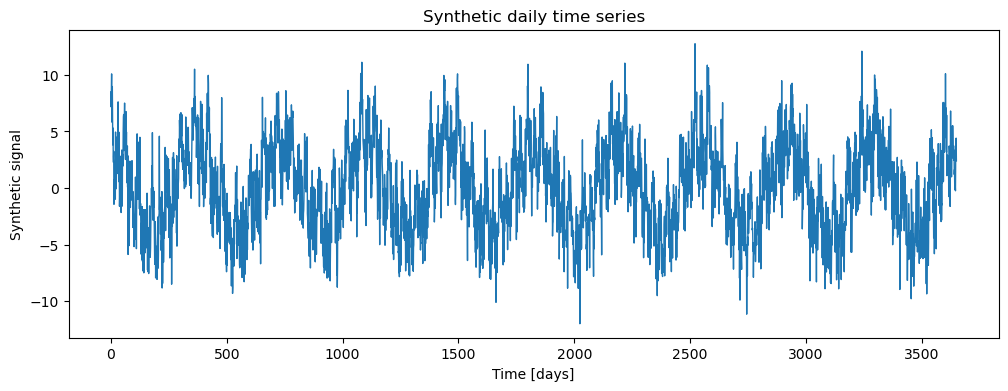

In [6]:
fig, ax = plt.subplots(figsize=(12, 4)) 
ax.plot(t, x, linewidth=1) 
ax.set_xlabel("Time [days]") 
ax.set_ylabel("Synthetic signal") 
ax.set_title("Synthetic daily time series") 
plt.show()

6. Compute the Fourier transform

For real-valued time series, we can use np.fft.rfft.

The function rfft means “real fast Fourier transform”. It is designed for real-valued data and only returns the non-negative frequencies.

This is convenient because climate variables such as OLR, SST, and winds are real numbers.

### A content subsection
Divide and conquer your objectives with Markdown subsections, which will populate the helpful navbar in Jupyter Lab and here on the Jupyter Book!

In [ ]:
# some subsection code
a = [1, 2, 3, 4, 5]
[i + 2 for i in a]

### Another content subsection
Keep up the good work! A note, *try to avoid using code comments as narrative*, and instead let them only exist as brief clarifications where necessary.

## Your second content section
Here we can move on to our second objective, and we can demonstrate...

### A subsection to the second section

#### a quick demonstration

##### of further and further

###### header levels

as well as $m = a * t / h$ text! Similarly, you have access to other $\LaTeX$ equation [**functionality**](https://jupyter-notebook.readthedocs.io/en/stable/examples/Notebook/Typesetting%20Equations.html) via MathJax:

\begin{align}
\dot{x} & = \sigma(y-x) \\
\dot{y} & = \rho x - y - xz \\
\dot{z} & = -\beta z + xy
\end{align}

Check out [**any number of helpful Markdown resources**](https://www.markdownguide.org/basic-syntax/) for further customizing your notebooks and the [**MyST Syntax Overview**](https://mystmd.org/guide/syntax-overview) for MyST-specific formatting information. Don't hesitate to ask questions if you have problems getting it to look *just right*.

## Last Section

You can add [admonitions using MyST syntax](https://mystmd.org/guide/admonitions):

:::{note}
Your relevant information here!
:::

Some other admonitions you can put in ([there are 10 total](https://mystmd.org/guide/admonitions#admonitions-list)):

:::{hint}
A helpful hint.
:::

:::{warning}
Be careful!
:::

:::{danger}
Scary stuff be here.
:::

We also suggest checking out MyST's [brief demonstration](https://mystmd.org/guide/notebook-configuration#notebook-cell-tags) on adding cell tags to your cells in Jupyter Notebook, Lab, or manually. See [this table](https://mystmd.org/guide/notebook-configuration#tbl-notebook-cell-tags) for a list of supported cell tags, which you can use to customize how your code content is displayed and even [demonstrate errors](https://mystmd.org/guide/execute-notebooks#allow-a-code-cell-to-error-without-failing-the-build) without altogether crashing our loyal army of machines!

---

## Summary
Add one final `---` marking the end of your body of content, and then conclude with a brief single paragraph summarizing at a high level the key pieces that were learned and how they tied to your objectives. Look to reiterate what the most important takeaways were.

### What's next?
Let Jupyter book tie this to the next (sequential) piece of content that people could move on to down below and in the sidebar. However, if this page uniquely enables your reader to tackle other nonsequential concepts throughout this book, or even external content, link to it here!

## Resources and references
Finally, be rigorous in your citations and references as necessary. Give credit where credit is due. Also, feel free to link to relevant external material, further reading, documentation, etc. Then you're done! Give yourself a quick review, a high five, and send us a pull request. A few final notes:
 - `Kernel > Restart Kernel and Run All Cells...` to confirm that your notebook will cleanly run from start to finish
 - `Kernel > Restart Kernel and Clear All Outputs...` before committing your notebook, our machines will do the heavy lifting
 - Take credit! Provide author contact information if you'd like; if so, consider adding information here at the bottom of your notebook
 - Give credit! Attribute appropriate authorship for referenced code, information, images, etc.
 - Only include what you're legally allowed: **no copyright infringement or plagiarism**
 
Thank you for your contribution!